In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.interpolate import RegularGridInterpolator

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
# Physical Constraints
G = 9.81                # grav acceleration constant [m/s^2]
MASS = 10.0             # vehicle mass [kg]
RHO = 1.225             # air density at sea level [kg/m^3]
C_D0 = 0.02             # zero-lift drag coefficient
C_D2 = 0.05             # induced drag coeffiicent
S_REF = 0.5             # refernce wing area
THRUST = 150.0          # constant engine trhust, powered phase only [N]

In [3]:
# Sensor param
Z_ACOUSTIC = 5000.0         # horizontal position of acoustic sensor
Z_RADAR = 15000.0           # horizontal position of radar
H_SENSOR = 0                # all sensors on ground (fixed)

# Acoustic model (powered phase only)
LAM_AC = 1e5                # acoustic intensity coefficient
N_AC = 4                    # speed exponent

# Doppler model
LAM_DOP = 1e5               # Doppler intensity coefficient

# RCS model
LAM_RCS = 1e5               # RCS intensity coefficient
SIGMA_0 = 1.0               # peak RCS value [m^2]
GAMMA_MIN = 0.0             # aspect angle of minimum RCS [rad]

In [4]:
# Mission param
Z_START = 0.0
H_START = 100.0
V_START = 80.0
Z_GOAL = 20000.0
H_GOAL = 0.0
EPS_GOAL = 200.0            # goal acceptance tolerance [m]
V_STALL = 30.0
V_MAX = 150.0

# Cost weights
ALPHA_1 = 1.0               # weight on detection probability PD
ALPHA_2 = 1e-3              # weight on flight time T

# SAC temperature
ALPHA_TEMP = 1.0            # entropy temperature (higher = more stochastic)

# Simulation
DT = 1.0                    # time step for trajectory integration [sec]
T_MAX = 1000.0              # maximum allowed flight time [s]

In [5]:
# State space grid
N_Z = 50
N_H = 30
N_V = 20

Z_MIN, Z_MAX = Z_START, Z_GOAL
H_MIN, H_MAX = 0.0, 5000.0
V_MIN, V_MAX = V_STALL, V_MAX

z_grid = np.linspace(Z_MIN, Z_MAX, N_Z)
h_grid = np.linspace(H_MIN, H_MAX, N_H)
v_grid = np.linspace(V_MIN, V_MAX, N_V)

# Environment Setup

In [6]:
# Sensor positions
sensors = {
    'acoustic': {'z': Z_ACOUSTIC, 'h': H_SENSOR},
    'radar': {'z': Z_RADAR, 'h': H_SENSOR},
}

# Goal definition
goal = {
    'z': Z_GOAL,
    'h': H_GOAL,
}

def reached_goal(z, h):
    dist = np.sqrt((z-goal['z'])**2 + (h-goal['h'])**2)
    return dist <= EPS_GOAL

def in_bounds(z, h, v):
    # Check grid bounds
    return (Z_MIN <= z <= Z_MAX and
            H_MIN <= h <= H_MAX and
            V_MIN <= v <= V_MAX
    )

# Dynamics Model

In [7]:
def drag_force(v):
    return 0.5 * RHO * v**2 * S_REF * C_D0

In [8]:
def powered_dynamics(t, state, theta):
    # EOM in powered phase
    z, h, v = state
    D = drag_force(v)

    zdot = v*np.cos(theta)
    hdot = v*np.sin(theta)
    vdot = (THRUST - D) / MASS - G*np.sin(theta)

    return np.array([zdot, hdot, vdot])

In [9]:
def glide_dynamics(t, state, gamma):
    # EOM in glide phase
    z, h, v = state

    # if v <= V_STALL:
    #     v = V_STALL
    v = max(v, V_STALL)

    D = drag_force(v)
    zdot = v*np.cos(gamma)
    hdot = -v*np.sin(gamma)
    vdot = -D / MASS - G*np.sin(gamma)

    if v <= V_STALL and vdot < 0:
        vdot = 0.0

    return np.array([zdot, hdot, vdot])

In [10]:
# Sanity check
state0 = np.array([Z_START, H_START, V_START])
print("--- Powered Dynamics at theta = 5 deg ---")
dpowered = powered_dynamics(0, state0, np.deg2rad(5))
print(f'zdot = {dpowered[0]:.2f} m/s')
print(f'hdot = {dpowered[1]:.2f} m/s')
print(f'vdot = {dpowered[2]:.2f} m/s^2')

print("--- Glided Dynamics at theta = 5 deg ---")
dglide = powered_dynamics(0, state0, np.deg2rad(5))
print(f'zdot = {dglide[0]:.2f} m/s')
print(f'hdot = {dglide[1]:.2f} m/s')
print(f'vdot = {dglide[2]:.2f} m/s^2')

--- Powered Dynamics at theta = 5 deg ---
zdot = 79.70 m/s
hdot = 6.97 m/s
vdot = 10.23 m/s^2
--- Glided Dynamics at theta = 5 deg ---
zdot = 79.70 m/s
hdot = 6.97 m/s
vdot = 10.23 m/s^2


In [11]:
state_test = np.array([5000.0, 1500.0, 80.0])
gamma_test = np.radians(5)
d = glide_dynamics(0, state_test, gamma_test)
print(f'zdot = {d[0]:.2f}')
print(f'hdot = {d[1]:.2f}')
print(f'vdot = {d[2]:.2f}')

zdot = 79.70
hdot = -6.97
vdot = -4.77


# Sensor Models

In [12]:
def sensor_range(z, h, z_sensor):
    # Compute range to sensor
    return np.maximum(np.sqrt((z-z_sensor)**2 + h**2), 1.0)

def radial_velocity(z, h, zdot, hdot, z_sensor):
    # Compute radial velcoity
    r = sensor_range(z, h, z_sensor)
    v_r = ((z-z_sensor)*zdot + h*hdot) / r
    return v_r

def aspect_angle(z, h, z_sensor):
    # Compute elevation angle from ground sensor upto the attacker
    delta_z = np.abs(z - z_sensor)
    gamma_asp = np.arctan2(h, delta_z)
    return gamma_asp

In [13]:
# Acoustic Sensor
def lambda_acoustic(z, h, v, mode, z_sensor):
    # Instantaneous acoustic detection
    if mode == 'glide':
        return 0.0
    else:
        r = sensor_range(z, h, z_sensor)
        return LAM_AC*(v**N_AC) / (r**2)

In [14]:
# Radar
def lambda_doppler(z, h, zdot, hdot, z_sensor):
    # Instantaneous doppler detection
    r = sensor_range(z, h, z_sensor)
    v_r = radial_velocity(z, h, zdot, hdot, z_sensor)
    return LAM_DOP * (v_r**2) / (r**4)

def lambda_rcs(z, h, zdot, hdot, z_sensor):
    # Instantaneous RCS detection
    r = sensor_range(z, h, z_sensor)
    gamma_asp = aspect_angle(z, h, z_sensor)
    sigma = SIGMA_0 * np.cos(gamma_asp - GAMMA_MIN)**2
    return LAM_RCS * sigma / (r**4)

In [15]:
# Total instantaneous detection intensity
def lambda_total(z, h, v, zdot, hdot, mode, sensors):
    z_ac = sensors['acoustic']['z']
    z_rad = sensors['radar']['z']
    
    lam_ac = lambda_acoustic(z, h, v, mode, z_ac)
    lam_dop = lambda_doppler(z, h, zdot, hdot, z_rad)
    lam_rcs = lambda_rcs(z, h, zdot, hdot, z_rad)

    return lam_ac + lam_dop + lam_rcs

In [16]:
# Cumulative PD from trajectory
def compute_pd(trajectory, sensors):
    cumulative_intensity = 0.0
    pd_seris = []

    for i in range(len(trajectory)-1):
        s = trajectory[i]
        dt_i = trajectory[i+1]['t'] - trajectory[i]['t']

        lam = lambda_total(s['z'], s['h'], s['v'],
                           s['zdot'], s['hdot'], s['mode'], sensors)
        
        cumulative_intensity += lam * dt_i
        pd_seris.append(1.0 - np.exp(-cumulative_intensity))

    pd_total = 1.0 - np.exp(-cumulative_intensity)
    return pd_total, np.array(pd_seris)

In [17]:
# Sanity check: evaluate lambda_total at a few points
test_state = {
    'z': 5000.0, 'h': 1000.0, 'v': 80.0,
    'zdot': 79.0, 'hdot': 7.0, 'mode': 'powered'
}
 
lam = lambda_total(
    test_state['z'], test_state['h'], test_state['v'],
    test_state['zdot'], test_state['hdot'],
    test_state['mode'], sensors
)
print(f"Lambda total (powered, near acoustic sensor): {lam:.6f} /s")
 
test_state['mode'] = 'glide'
lam_g = lambda_total(
    test_state['z'], test_state['h'], test_state['v'],
    test_state['zdot'], test_state['hdot'],
    test_state['mode'], sensors
)
print(f"Lambda total (glide,   near acoustic sensor): {lam_g:.6f} /s")
 
print(f"\nDifference (should equal lambda_acoustic): {lam - lam_g:.6f} /s")

Lambda total (powered, near acoustic sensor): 4096000.000000 /s
Lambda total (glide,   near acoustic sensor): 0.000000 /s

Difference (should equal lambda_acoustic): 4096000.000000 /s


# Trajectory Simulator

In [18]:
def simulate_trajectory(policy_powered, policy_glide, switch_condition, sensors, dt=DT, t_max=T_MAX):
    # Simulate full attacker trajectory from start to goal
    # --- initial conditoins ---
    t = 0.0
    state = np.array([Z_START, H_START, V_START])
    mode = 'powered'

    trajectory = []
    info = {
        't_switch': None,
        'z_switch': None,
        'h_switch': None,
        'reached_goal': False,
        'final_time': None,
    }

    # --- main loop ---
    while t < t_max:
        z, h, v = state
        
        # Compute velocity components from current state and control
        if mode == 'powered':
            theta = policy_powered(t, z, h, v)
            zdot = v*np.cos(theta)
            hdot = v*np.sin(theta)
        else:
            gamma = policy_glide(t, z, h, v)
            zdot = v*np.cos(gamma)
            hdot = -v*np.sin(gamma)

        # record current step
        trajectory.append({
            't': t,
            'z': z,
            'h': h,
            'v': v,
            'zdot': zdot,
            'hdot': hdot,
            'mode': mode,
        })

        # Check terminal condition
        if reached_goal(z, h):
            info['reached_goal'] = True
            info['final_time'] = t
            break
        
        if h <= 0.0 and not reached_goal(z, h):
            # attacker hit the ground before goal
            info['final_time'] = t
            break

        # Check mode switch
        if mode == 'powered' and switch_condition(t, z, h, v):
            mode = 'glide'
            info['t_switch'] = t
            info['z_switch'] = z
            info['h_switch'] = h
            print(f'SWITCH TRIGGERED: t={t:.1f}, z={z:.0f}, h={h:.0f}, v={v:.2f}')

        # integrate one step forwrard with RK4
        if mode == 'powered':
            theta = policy_powered(t, z, h, v)
            dynamics = lambda t_, s, th=theta: powered_dynamics(t_, s, th)
            # def dynamics(t_, s): return powered_dynamics(t_, s, theta)
        else:
            gamma = policy_glide(t, z, h, v)
            # def dynamics(t_, s): return glide_dynamics(t_, s, gamma)
            dynamics = lambda t_, s, gm=gamma: glide_dynamics(t_, s, gm)

        sol = solve_ivp(
            dynamics,
            t_span = (t, t+dt),
            y0 = state,
            method = 'RK45',
            max_step = dt/5,
        )

        state = sol.y[:,-1]
        t = t+dt

        # TEMPORARY DEBUG
        print(f"t={t:.1f}  z={state[0]:.0f}  h={state[1]:.0f}  v={state[2]:.2f}  mode={mode}")
    return trajectory, info

In [19]:
def constant_theta_policy(theta_deg):
    # returns a powered policy that always commands a fixed climb angle
    theta = np.radians(theta_deg)
    def policy(t, z, h, v):
        return theta
    return policy

def constant_gamma_policy(gamma_deg):
    # returns a glide policy that always commands a fixed glide angle
    gamma = np.deg2rad(gamma_deg)
    def policy(t, z, h, v):
        return gamma
    return policy

def fixed_altitude_switch(h_threshold):
    # returns a switch condition that trigges when attacker reaches a fixed altitude threshold
    def condition(t, z, h, v):
        return h >= h_threshold
    return condition

t=1.0  z=83  h=115  v=88.92  mode=powered
t=2.0  z=175  h=131  v=96.91  mode=powered
t=3.0  z=274  h=148  v=104.02  mode=powered
t=4.0  z=379  h=167  v=110.27  mode=powered
t=5.0  z=491  h=187  v=115.73  mode=powered
t=6.0  z=607  h=207  v=120.48  mode=powered
t=7.0  z=728  h=228  v=124.57  mode=powered
t=8.0  z=852  h=250  v=128.09  mode=powered
t=9.0  z=980  h=273  v=131.09  mode=powered
t=10.0  z=1110  h=296  v=133.65  mode=powered
t=11.0  z=1243  h=319  v=135.82  mode=powered
t=12.0  z=1378  h=343  v=137.66  mode=powered
t=13.0  z=1514  h=367  v=139.21  mode=powered
t=14.0  z=1652  h=391  v=140.52  mode=powered
t=15.0  z=1791  h=416  v=141.63  mode=powered
t=16.0  z=1931  h=440  v=142.56  mode=powered
t=17.0  z=2072  h=465  v=143.33  mode=powered
t=18.0  z=2213  h=490  v=143.99  mode=powered
t=19.0  z=2355  h=515  v=144.54  mode=powered
t=20.0  z=2498  h=540  v=145.00  mode=powered
t=21.0  z=2641  h=566  v=145.38  mode=powered
t=22.0  z=2784  h=591  v=145.70  mode=powered
t=23.0  z

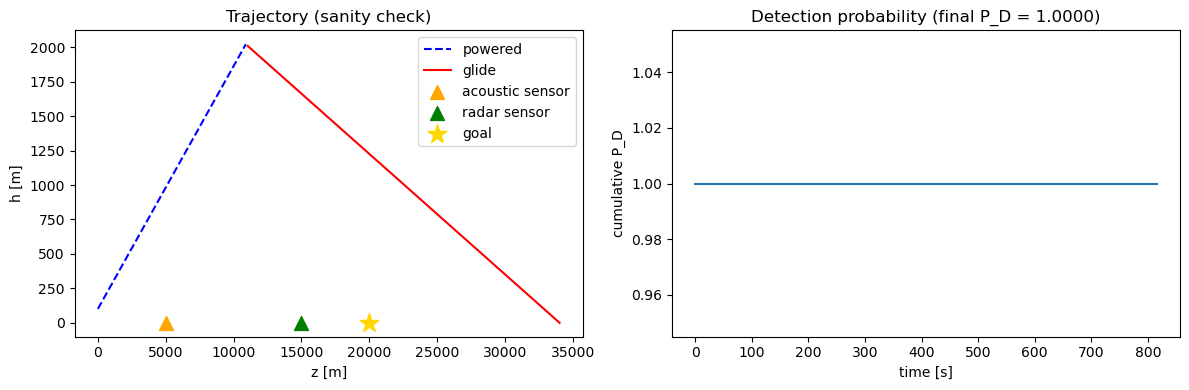

In [20]:
# Run a test trajectory with constant policies
traj, info = simulate_trajectory(
    policy_powered   = constant_theta_policy(10),
    policy_glide     = constant_gamma_policy(5),
    switch_condition = fixed_altitude_switch(2000.0),
    sensors          = sensors,
    # t_max = 200.0
)
 
# Print summary
# print(f"Reached goal : {info['reached_goal']}")
# print(f"Final time   : {info['final_time']:.1f} s")
# print(f"Switch at    : t={info['t_switch']:.1f}s, "
#       f"z={info['z_switch']:.0f}m, h={info['h_switch']:.0f}m")
 
# Compute P_D
pd_final, pd_series = compute_pd(traj, sensors)
print(f"Final P_D    : {pd_final:.4f}")
 
# Quick plot
times = [s['t'] for s in traj]
zs    = [s['z'] for s in traj]
hs    = [s['h'] for s in traj]
modes = [s['mode'] for s in traj]
 
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
 
# Trajectory plot
pow_idx = [i for i, m in enumerate(modes) if m == 'powered']
gli_idx = [i for i, m in enumerate(modes) if m == 'glide']
 
axes[0].plot([zs[i] for i in pow_idx], [hs[i] for i in pow_idx],
             'b--', label='powered')
axes[0].plot([zs[i] for i in gli_idx], [hs[i] for i in gli_idx],
             'r-',  label='glide')
axes[0].scatter([sensors['acoustic']['z']], [0], marker='^',
                color='orange', s=100, label='acoustic sensor', zorder=5)
axes[0].scatter([sensors['radar']['z']], [0], marker='^',
                color='green',  s=100, label='radar sensor',    zorder=5)
axes[0].scatter([goal['z']], [goal['h']], marker='*',
                color='gold', s=200, label='goal', zorder=5)
axes[0].set_xlabel('z [m]')
axes[0].set_ylabel('h [m]')
axes[0].set_title('Trajectory (sanity check)')
axes[0].legend()
 
# P_D plot
axes[1].plot(times[:-1], pd_series)
axes[1].set_xlabel('time [s]')
axes[1].set_ylabel('cumulative P_D')
axes[1].set_title(f'Detection probability (final P_D = {pd_final:.4f})')
 
plt.tight_layout()
plt.show()

# Bellman

In [21]:
def compute_cost(trajectory, sensors):
    P_D, _ = compute_pd(trajectory, sensors)

    T = trajectory[-1]['t']

    J = ALPHA_1*P_D + ALPHA_2*T

    return J, P_D, T

In [22]:
J, P_D, T = compute_cost(traj, sensors)
print(f"P_D  : {P_D:.4f}")
print(f"T    : {T:.1f} s")
print(f"J    : {J:.4f}")
print(f"Check: {ALPHA_1*P_D + ALPHA_2*T:.4f}  (should match J)")

P_D  : 1.0000
T    : 817.0 s
J    : 1.8170
Check: 1.8170  (should match J)


In [23]:
def rk4_step_vectorized(f, state, action, dt):
    k1 = f(state, action)
    k2 = f(state + dt/2 * k1, action)
    k3 = f(state + dt/2 * k2, action)
    k4 = f(state + dt   * k3, action)
    return state + dt/6 * (k1 + 2*k2 + 2*k3 + k4)

## Bellman Solver

In [24]:
# Action grids (1 degree resolution)
theta_grid_deg = np.arange(15, 61, 1)        # [15, 16, ..., 60] degrees
gamma_grid_deg = np.arange(1,  46, 1)        # [1,  2,  ..., 45] degrees

theta_grid = np.radians(theta_grid_deg)      # convert to radians
gamma_grid = np.radians(gamma_grid_deg)

N_THETA = len(theta_grid)                    # 46
N_GAMMA = len(gamma_grid)                    # 45

print(f"N_THETA : {N_THETA}")
print(f"N_GAMMA : {N_GAMMA}")
print(f"Total state-action pairs (glide)   : {N_Z*N_H*N_V*N_GAMMA:,}")
print(f"Total state-action pairs (powered) : {N_Z*N_H*N_V*N_THETA:,}")

N_THETA : 46
N_GAMMA : 45
Total state-action pairs (glide)   : 1,350,000
Total state-action pairs (powered) : 1,380,000


In [25]:
def powered_dynamics_vec(Z, H, V, theta):
    D = 0.5 * RHO * V**2 * S_REF * C_D0

    ZDOT = V * np.cos(theta)
    HDOT = V * np.sin(theta)
    VDOT = (THRUST - D) / MASS - G * np.sin(theta)

    return ZDOT, HDOT, VDOT


def glide_dynamics_vec(Z, H, V, gamma):
    V_clamped = np.maximum(V, V_STALL)
    D = 0.5 * RHO * V_clamped**2 * S_REF * C_D0

    ZDOT =   V_clamped * np.cos(gamma)
    HDOT = - V_clamped * np.sin(gamma)
    VDOT = - D / MASS - G * np.sin(gamma)

    # prevent further deceleration below stall
    VDOT = np.where(V_clamped <= V_STALL, np.maximum(VDOT, 0.0), VDOT)

    return ZDOT, HDOT, VDOT

In [26]:
def stage_cost_vec(Z, H, ZDOT, HDOT, V, mode, sensors):
    # Compute instantaneous detection intensity Lambda at every
    # state-action pair simultaneously.

    z_ac  = sensors['acoustic']['z']
    z_rad = sensors['radar']['z']

    # ranges -- shape (N_Z, N_H, N_V, N_ACTIONS)
    R_ac  = np.maximum(np.sqrt((Z - z_ac)**2  + H**2), 1.0)
    R_rad = np.maximum(np.sqrt((Z - z_rad)**2 + H**2), 1.0)

    # radial velocity toward radar
    V_R = ((Z - z_rad) * ZDOT + H * HDOT) / R_rad

    # aspect angle to radar
    GAMMA_ASP = np.arctan2(H, np.abs(Z - z_rad))

    # acoustic (powered only)
    if mode == 'powered':
        LAM_ACOUSTIC = LAM_AC * (V ** N_AC) / (R_ac ** 2)
    else:
        LAM_ACOUSTIC = 0.0

    # doppler
    LAM_DOPPLER = LAM_DOP * (V_R ** 2) / (R_rad ** 4)

    # RCS
    SIGMA       = SIGMA_0 * np.cos(GAMMA_ASP - GAMMA_MIN) ** 2
    LAM_RCS_VAL = LAM_RCS * SIGMA / (R_rad ** 4)

    LAMBDA = LAM_ACOUSTIC + LAM_DOPPLER + LAM_RCS_VAL

    return LAMBDA

In [27]:
def precompute_transitions(dynamics_vec, action_grid, dt=DT):
    # Precompute next states for every (state, action) pair using RK4.

    N_ACT = len(action_grid)

    # expand state grids to (N_Z, N_H, N_V, 1) for broadcasting
    Z = z_grid[:, np.newaxis, np.newaxis, np.newaxis] * np.ones((1, N_H, N_V, N_ACT))
    H = h_grid[np.newaxis, :, np.newaxis, np.newaxis] * np.ones((N_Z, 1, N_V, N_ACT))
    V = v_grid[np.newaxis, np.newaxis, :, np.newaxis] * np.ones((N_Z, N_H, 1, N_ACT))

    # expand action grid to (1, 1, 1, N_ACTIONS)
    A = action_grid[np.newaxis, np.newaxis, np.newaxis, :]
    A = np.broadcast_to(A, (N_Z, N_H, N_V, N_ACT)).copy()

    # RK4 step -- all state-action pairs simultaneously
    k1z, k1h, k1v = dynamics_vec(Z, H, V,        A)
    k2z, k2h, k2v = dynamics_vec(Z, H, V + dt/2*k1v, A)
    k3z, k3h, k3v = dynamics_vec(Z, H, V + dt/2*k2v, A)
    k4z, k4h, k4v = dynamics_vec(Z, H, V + dt   *k3v, A)

    Z_next = Z + dt/6 * (k1z + 2*k2z + 2*k3z + k4z)
    H_next = H + dt/6 * (k1h + 2*k2h + 2*k3h + k4h)
    V_next = V + dt/6 * (k1v + 2*k2v + 2*k3v + k4v)

    # clamp next state to physical bounds
    V_next = np.clip(V_next, V_STALL, V_MAX)
    H_next = np.maximum(H_next, 0.0)

    return Z_next, H_next, V_next, k1z, k1h


print("Precomputing glide transitions...")
import time
t0 = time.time()
Z_next_G, H_next_G, V_next_G, ZDOT_G, HDOT_G = precompute_transitions(
    glide_dynamics_vec, gamma_grid
)
print(f"  Glide done in {time.time()-t0:.1f}s  shape: {Z_next_G.shape}")

t0 = time.time()
print("Precomputing powered transitions...")
Z_next_P, H_next_P, V_next_P, ZDOT_P, HDOT_P = precompute_transitions(
    powered_dynamics_vec, theta_grid
)
print(f"  Powered done in {time.time()-t0:.1f}s  shape: {Z_next_P.shape}")

Precomputing glide transitions...
  Glide done in 0.1s  shape: (50, 30, 20, 45)
Precomputing powered transitions...
  Powered done in 0.1s  shape: (50, 30, 20, 46)


In [28]:
print("Precomputing stage costs...")

t0 = time.time()

# expand state grids to 4D for stage cost computation
Z4_G = np.broadcast_to(
    z_grid[:, np.newaxis, np.newaxis, np.newaxis], (N_Z, N_H, N_V, N_GAMMA)
).copy()
H4_G = np.broadcast_to(
    h_grid[np.newaxis, :, np.newaxis, np.newaxis], (N_Z, N_H, N_V, N_GAMMA)
).copy()
V4_G = np.broadcast_to(
    v_grid[np.newaxis, np.newaxis, :, np.newaxis], (N_Z, N_H, N_V, N_GAMMA)
).copy()

Z4_P = np.broadcast_to(
    z_grid[:, np.newaxis, np.newaxis, np.newaxis], (N_Z, N_H, N_V, N_THETA)
).copy()
H4_P = np.broadcast_to(
    h_grid[np.newaxis, :, np.newaxis, np.newaxis], (N_Z, N_H, N_V, N_THETA)
).copy()
V4_P = np.broadcast_to(
    v_grid[np.newaxis, np.newaxis, :, np.newaxis], (N_Z, N_H, N_V, N_THETA)
).copy()

# compute Lambda at every state-action pair
# LAMBDA_G = stage_cost_vec(Z4_G, H4_G, ZDOT_G, HDOT_G, V4_G, 'glide',   sensors)
# LAMBDA_P = stage_cost_vec(Z4_P, H4_P, ZDOT_P, HDOT_P, V4_P, 'powered', sensors)
LAMBDA_G = np.clip(
    stage_cost_vec(Z4_G, H4_G, ZDOT_G, HDOT_G, V4_G, 'glide', sensors),
    0.0, 1.0
)
LAMBDA_P = np.clip(
    stage_cost_vec(Z4_P, H4_P, ZDOT_P, HDOT_P, V4_P, 'powered', sensors),
    0.0, 1.0
)

# running cost per timestep DT
# stage_cost = detection_intensity * dt + alpha_2 * dt
STAGE_G = ALPHA_1 * LAMBDA_G * DT + ALPHA_2 * DT
STAGE_P = ALPHA_1 * LAMBDA_P * DT + ALPHA_2 * DT
# STAGE_G = ALPHA_1 * LAMBDA_G * 10.0 + ALPHA_2 * 10.0
STAGE_P = ALPHA_1 * LAMBDA_P * 10.0 + ALPHA_2 * 10.0

print(f"Stage costs computed in {time.time()-t0:.1f}s")
print(f"STAGE_G shape: {STAGE_G.shape}")
print(f"STAGE_P shape: {STAGE_P.shape}")
print(f"LAMBDA_G range: [{LAMBDA_G.min():.2e}, {LAMBDA_G.max():.2e}]")
print(f"LAMBDA_P range: [{LAMBDA_P.min():.2e}, {LAMBDA_P.max():.2e}]")

Precomputing stage costs...
Stage costs computed in 0.1s
STAGE_G shape: (50, 30, 20, 45)
STAGE_P shape: (50, 30, 20, 46)
LAMBDA_G range: [1.32e-12, 1.00e+00]
LAMBDA_P range: [1.00e+00, 1.00e+00]


In [29]:
print(f"ZDOT_G sample (center): {ZDOT_G[25,15,10,22]:.4f}")
print(f"HDOT_G sample (center): {HDOT_G[25,15,10,22]:.4f}")
print(f"Z_next_G sample: {Z_next_G[25,15,10,22]:.1f}")
print(f"H_next_G sample: {H_next_G[25,15,10,22]:.1f}")
print(f"V_next_G sample: {V_next_G[25,15,10,22]:.1f}")

# check raw lambda components at a known point
z_test = 10000.0  # midpoint
h_test = 1000.0
v_test = 80.0
zdot_test = v_test * np.cos(np.radians(10))
hdot_test = -v_test * np.sin(np.radians(10))

r_rad = np.sqrt((z_test - Z_RADAR)**2 + h_test**2)
v_r = ((z_test - Z_RADAR)*zdot_test + h_test*hdot_test) / r_rad
gamma_asp = np.arctan2(h_test, abs(z_test - Z_RADAR))
sigma = SIGMA_0 * np.cos(gamma_asp - GAMMA_MIN)**2

lam_dop = LAM_DOP * v_r**2 / r_rad**4
lam_rcs = LAM_RCS * sigma / r_rad**4

print(f"\nManual check at z=10km, h=1km, v=80:")
print(f"  r_radar  = {r_rad:.1f} m")
print(f"  v_r      = {v_r:.4f} m/s")
print(f"  lam_dop  = {lam_dop:.6e}")
print(f"  lam_rcs  = {lam_rcs:.6e}")

ZDOT_G sample (center): 85.7523
HDOT_G sample (center): -36.3997
Z_next_G sample: 10285.8
H_next_G sample: 2551.5
V_next_G sample: 84.5

Manual check at z=10km, h=1km, v=80:
  r_radar  = 5099.0 m
  v_r      = -79.9791 m/s
  lam_dop  = 9.462508e-07
  lam_rcs  = 1.422394e-10


In [30]:
def bellman_solve(max_iter=200, tol=1e-3):
    # Solve the Bellman equation via value iteration.
    # INF = 1e6   # large penalty for infeasible states
    INF = 100

    # --- initialize value functions ---
    V_G = np.full((N_Z, N_H, N_V), INF)
    V_P = np.full((N_Z, N_H, N_V), INF)

    # --- terminal condition: goal states have zero cost ---
    for iz in range(N_Z):
        for ih in range(N_H):
            dist = np.sqrt((z_grid[iz] - goal['z'])**2 +
                           (h_grid[ih] - goal['h'])**2)
            if dist <= EPS_GOAL:
                V_G[iz, ih, :] = 0.0
                V_P[iz, ih, :] = 0.0

    # --- build interpolators (updated each iteration) ---
    def make_interp(V):
        return RegularGridInterpolator(
            (z_grid, h_grid, v_grid),
            V,
            method='linear',
            bounds_error=False,
            fill_value=INF,    # out-of-bounds = infeasible
        )

    print(f"Starting Bellman iteration (max_iter={max_iter}, tol={tol})")

    for k in range(max_iter):
        V_G_old = V_G.copy()
        V_P_old = V_P.copy()

        # ── GLIDE UPDATE ──────────────────────────────────────────
        interp_G = make_interp(V_G_old)

        # query next-state values for all (state, action) pairs
        # next states shape: (N_Z, N_H, N_V, N_GAMMA)
        pts = np.stack([
            Z_next_G.ravel(),
            H_next_G.ravel(),
            V_next_G.ravel()
        ], axis=-1)                              # shape (N_Z*N_H*N_V*N_GAMMA, 3)

        V_next_vals = interp_G(pts).reshape(N_Z, N_H, N_V, N_GAMMA)

        # Q-values for glide
        Q_G = STAGE_G + V_next_vals             # shape (N_Z, N_H, N_V, N_GAMMA)

        # optimal glide action at each state
        pi_G  = np.argmin(Q_G, axis=-1)         # shape (N_Z, N_H, N_V)
        V_G   = np.min(Q_G,    axis=-1)         # shape (N_Z, N_H, N_V)

        # preserve terminal states
        V_G[V_G_old == 0.0] = 0.0

        # ── POWERED UPDATE ────────────────────────────────────────
        interp_P = make_interp(V_P_old)
        interp_G_curr = make_interp(V_G)        # use updated V_G for switch option

        pts_P = np.stack([
            Z_next_P.ravel(),
            H_next_P.ravel(),
            V_next_P.ravel()
        ], axis=-1)

        V_next_vals_P = interp_P(pts_P).reshape(N_Z, N_H, N_V, N_THETA)

        # Q-values for staying powered
        Q_P = STAGE_P + V_next_vals_P           # shape (N_Z, N_H, N_V, N_THETA)

        # best powered action
        best_Q_P  = np.min(Q_P,    axis=-1)     # shape (N_Z, N_H, N_V)
        best_pi_P = np.argmin(Q_P, axis=-1)

        # switch option: cost of switching = V_G at current state
        # (no stage cost for the switch itself, just transition)
        switch_cost = V_G                        # shape (N_Z, N_H, N_V)

        # choose: stay powered or switch to glide
        switch_is_better = switch_cost < best_Q_P

        V_P   = np.where(switch_is_better, switch_cost, best_Q_P)
        pi_P  = np.where(switch_is_better, N_THETA, best_pi_P)
        # pi_P = N_THETA means "switch to glide"

        # preserve terminal states
        V_P[V_P_old == 0.0] = 0.0

        # ── CONVERGENCE CHECK ─────────────────────────────────────
        mask_G = V_G < INF
        mask_P = V_P < INF

        if np.any(mask_G):
            delta_G = np.max(np.abs(V_G[mask_G] - V_G_old[mask_G]))
        else:
            delta_G = INF

        if np.any(mask_P):
            delta_P = np.max(np.abs(V_P[mask_P] - V_P_old[mask_P]))
        else:
            delta_P = INF

        delta = max(delta_G, delta_P)

        if k % 10 == 0 or k < 5:
            n_reached_G = np.sum(V_G < INF)
            n_reached_P = np.sum(V_P < INF)
            print(f"  iter {k:3d}  delta = {delta:.4f}  "
                  f"reached: G={n_reached_G}, P={n_reached_P}")

        if delta < tol:
            print(f"  Converged at iteration {k}  delta = {delta:.6f}")
            break

    return V_G, V_P, pi_G, pi_P


# run the solver
V_G, V_P, pi_G, pi_P = bellman_solve(max_iter=200, tol=1.0)

Starting Bellman iteration (max_iter=200, tol=1.0)
  iter   0  delta = 35.1322  reached: G=100, P=100
  iter   1  delta = 20.9227  reached: G=200, P=200
  iter   2  delta = 13.3305  reached: G=323, P=323
  iter   3  delta = 12.3227  reached: G=450, P=450
  iter   4  delta = 10.5264  reached: G=557, P=557
  iter  10  delta = 5.0744  reached: G=980, P=980
  iter  20  delta = 2.6929  reached: G=1538, P=1538
  iter  30  delta = 2.0363  reached: G=2077, P=2077
  iter  40  delta = 1.8044  reached: G=2631, P=2631
  iter  50  delta = 1.6370  reached: G=3241, P=3241
  iter  60  delta = 1.4791  reached: G=3891, P=3891
  iter  70  delta = 1.4011  reached: G=4590, P=4590
  iter  80  delta = 1.3139  reached: G=5333, P=5333
  iter  90  delta = 1.2399  reached: G=6120, P=6120
  iter 100  delta = 1.1905  reached: G=6953, P=6953
  iter 110  delta = 1.1324  reached: G=7832, P=7832
  iter 120  delta = 1.0941  reached: G=8744, P=8744
  iter 130  delta = 1.0543  reached: G=9674, P=9674
  iter 140  delta = 

In [31]:
print(f"\nV_G at z=0, h=100, v=80 : {V_G[0, 0, 5]:.4f}")
print(f"V_P at z=0, h=100, v=80 : {V_P[0, 0, 5]:.4f}")
print(f"V_G at z=10k, h=2k, v=80: {V_G[25, 12, 10]:.4f}")
print(f"V_P at z=10k, h=2k, v=80: {V_P[25, 12, 10]:.4f}")

# how many states have switch triggered
n_switch = np.sum(pi_P == N_THETA)
print(f"\nStates with switch triggered: {n_switch} of {N_Z*N_H*N_V}")


V_G at z=0, h=100, v=80 : 100.1480
V_P at z=0, h=100, v=80 : 100.1480
V_G at z=10k, h=2k, v=80: 100.1173
V_P at z=10k, h=2k, v=80: 100.1173

States with switch triggered: 30000 of 30000


In [32]:
print(f"STAGE_G max : {STAGE_G.max():.4f}")
print(f"STAGE_G min : {STAGE_G.min():.4f}")
print(f"STAGE_G mean: {STAGE_G.mean():.4f}")

print(f"\nLAMBDA_G max : {LAMBDA_G.max():.4f}")
print(f"LAMBDA_G mean: {LAMBDA_G.mean():.6f}")

# expected V* range
# trajectory ~500s, mean stage cost per second?
print(f"\nExpected V* order of magnitude: {STAGE_G.mean() * 50:.2f}")
# 50 steps at dt=10s = 500s trajectory

STAGE_G max : 1.0010
STAGE_G min : 0.0010
STAGE_G mean: 0.0018

LAMBDA_G max : 1.0000
LAMBDA_G mean: 0.000823

Expected V* order of magnitude: 0.09


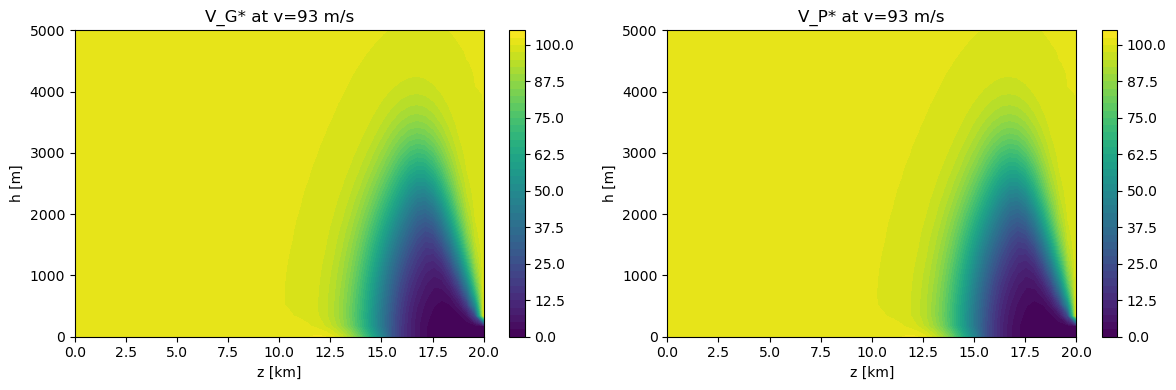

In [33]:
def extract_bellman_policy(V_G, V_P, pi_G, pi_P):
    # Build callable policy functions from Bellman solution.
    
    interp_piG = RegularGridInterpolator(
        (z_grid, h_grid, v_grid), pi_G,
        method='nearest',        # nearest for policy (index, not continuous)
        bounds_error=False,
        fill_value=0,
    )
    interp_piP = RegularGridInterpolator(
        (z_grid, h_grid, v_grid), pi_P,
        method='nearest',
        bounds_error=False,
        fill_value=0,
    )

    def policy_powered(t, z, h, v):
        idx = int(interp_piP([[z, h, v]])[0])
        if idx == N_THETA:
            # switch triggered -- return neutral theta
            return np.radians(15)
        return theta_grid[idx]

    def policy_glide(t, z, h, v):
        idx = int(interp_piG([[z, h, v]])[0])
        return gamma_grid[idx]

    def switch_condition(t, z, h, v):
        idx = int(interp_piP([[z, h, v]])[0])
        return idx == N_THETA

    return policy_powered, policy_glide, switch_condition


# extract policies
pol_pow, pol_gli, pol_sw = extract_bellman_policy(V_G, V_P, pi_G, pi_P)

# visualize the value function at a fixed v slice
iv_mid = N_V // 2

V_G_plot = np.where(V_G < 90, V_G, np.nan)
V_P_plot = np.where(V_P < 90, V_P, np.nan)

im0 = axes[0].contourf(z_grid/1000, h_grid, V_G_plot[:, :, iv_mid].T,
                        levels=50, cmap='viridis')
im1 = axes[1].contourf(z_grid/1000, h_grid, V_P_plot[:, :, iv_mid].T,
                        levels=50, cmap='viridis')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

im0 = axes[0].contourf(z_grid/1000, h_grid, V_G[:, :, iv_mid].T,
                        levels=50, cmap='viridis')
axes[0].set_xlabel('z [km]')
axes[0].set_ylabel('h [m]')
axes[0].set_title(f'V_G* at v={v_grid[iv_mid]:.0f} m/s')
plt.colorbar(im0, ax=axes[0])

im1 = axes[1].contourf(z_grid/1000, h_grid, V_P[:, :, iv_mid].T,
                        levels=50, cmap='viridis')
axes[1].set_xlabel('z [km]')
axes[1].set_ylabel('h [m]')
axes[1].set_title(f'V_P* at v={v_grid[iv_mid]:.0f} m/s')
plt.colorbar(im1, ax=axes[1])

plt.tight_layout()
plt.show()

In [34]:
# Roll out the Bellman policy
print("Rolling out Bellman policy...")

traj_bellman, info_bellman = simulate_trajectory(
    policy_powered   = pol_pow,
    policy_glide     = pol_gli,
    switch_condition = pol_sw,
    sensors          = sensors,
)

# compute cost
J_bellman, PD_bellman, T_bellman = compute_cost(traj_bellman, sensors)

# print summary
print(f"Reached goal : {info_bellman['reached_goal']}")
print(f"Final time   : {info_bellman['final_time']}")
print(f"Switch t     : {info_bellman['t_switch']}")
print(f"Switch z     : {info_bellman['z_switch']}")
print(f"Switch h     : {info_bellman['h_switch']}")
print(f"P_D          : {PD_bellman:.4f}")
print(f"T            : {T_bellman:.1f} s")
print(f"J            : {J_bellman:.4f}")

Rolling out Bellman policy...
SWITCH TRIGGERED: t=0.0, z=0, h=100, v=80.00
t=1.0  z=53  h=47  v=69.64  mode=glide
t=2.0  z=99  h=1  v=60.12  mode=glide
t=3.0  z=138  h=-38  v=51.28  mode=glide
Reached goal : False
Final time   : 3.0
Switch t     : 0.0
Switch z     : 0.0
Switch h     : 100.0
P_D          : 1.0000
T            : 3.0 s
J            : 1.0030


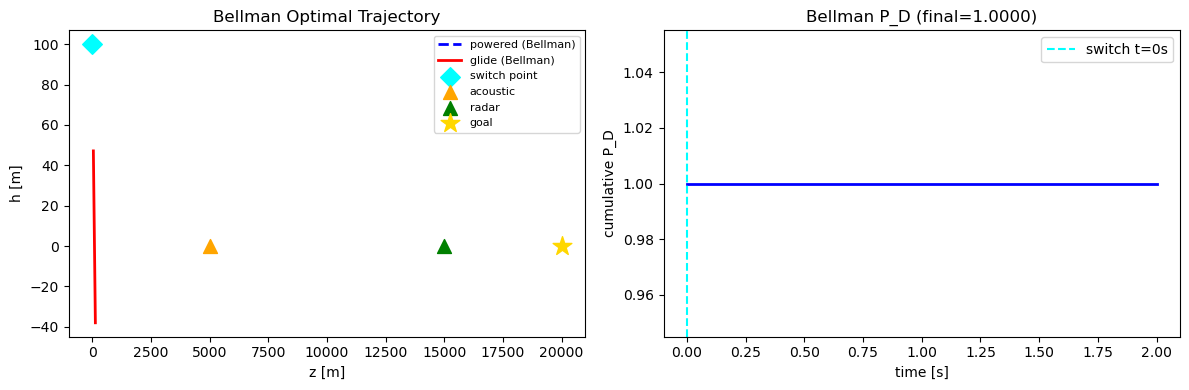

In [35]:
# extract trajectory arrays
times_b = [s['t']    for s in traj_bellman]
zs_b    = [s['z']    for s in traj_bellman]
hs_b    = [s['h']    for s in traj_bellman]
modes_b = [s['mode'] for s in traj_bellman]

pow_idx = [i for i, m in enumerate(modes_b) if m == 'powered']
gli_idx = [i for i, m in enumerate(modes_b) if m == 'glide']

pd_b, pd_series_b = compute_pd(traj_bellman, sensors)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- trajectory plot ---
axes[0].plot([zs_b[i] for i in pow_idx],
             [hs_b[i] for i in pow_idx],
             'b--', linewidth=2, label='powered (Bellman)')
axes[0].plot([zs_b[i] for i in gli_idx],
             [hs_b[i] for i in gli_idx],
             'r-',  linewidth=2, label='glide (Bellman)')

# mark switch point
if info_bellman['z_switch'] is not None:
    axes[0].scatter([info_bellman['z_switch']],
                    [info_bellman['h_switch']],
                    marker='D', color='cyan', s=100,
                    zorder=6, label='switch point')

# sensors and goal
axes[0].scatter([sensors['acoustic']['z']], [0],
                marker='^', color='orange', s=100,
                label='acoustic', zorder=5)
axes[0].scatter([sensors['radar']['z']], [0],
                marker='^', color='green', s=100,
                label='radar', zorder=5)
axes[0].scatter([goal['z']], [goal['h']],
                marker='*', color='gold', s=200,
                label='goal', zorder=5)

axes[0].set_xlabel('z [m]')
axes[0].set_ylabel('h [m]')
axes[0].set_title('Bellman Optimal Trajectory')
axes[0].legend(fontsize=8)

# --- P_D plot ---
axes[1].plot(times_b[:-1], pd_series_b, 'b-', linewidth=2)
if info_bellman['t_switch'] is not None:
    axes[1].axvline(info_bellman['t_switch'],
                    color='cyan', linestyle='--',
                    label=f"switch t={info_bellman['t_switch']:.0f}s")
axes[1].set_xlabel('time [s]')
axes[1].set_ylabel('cumulative P_D')
axes[1].set_title(f'Bellman P_D (final={PD_bellman:.4f})')
axes[1].legend()

plt.tight_layout()
plt.show()

In [36]:
# Compare stage costs between powered and glide
# at the acoustic sensor location
iz_ac = np.argmin(np.abs(z_grid - Z_ACOUSTIC))  # grid index nearest acoustic sensor
ih_1k = np.argmin(np.abs(h_grid - 1000.0))      # grid index nearest h=1000m
iv_mid = N_V // 2

print(f"At z={z_grid[iz_ac]:.0f}m, h={h_grid[ih_1k]:.0f}m, v={v_grid[iv_mid]:.0f}m/s:")
print(f"  STAGE_G : {STAGE_G[iz_ac, ih_1k, iv_mid, 22]:.6f}")
print(f"  STAGE_P : {STAGE_P[iz_ac, ih_1k, iv_mid, 22]:.6f}")
print(f"  LAMBDA_G: {LAMBDA_G[iz_ac, ih_1k, iv_mid, 22]:.6f}")
print(f"  LAMBDA_P: {LAMBDA_P[iz_ac, ih_1k, iv_mid, 22]:.6f}")
print(f"  Difference: {STAGE_P[iz_ac, ih_1k, iv_mid, 22] - STAGE_G[iz_ac, ih_1k, iv_mid, 22]:.6f}")

# Also check far from acoustic sensor
iz_far = np.argmin(np.abs(z_grid - 15000.0))
print(f"\nAt z={z_grid[iz_far]:.0f}m (near radar), h={h_grid[ih_1k]:.0f}m:")
print(f"  STAGE_G : {STAGE_G[iz_far, ih_1k, iv_mid, 22]:.6f}")
print(f"  STAGE_P : {STAGE_P[iz_far, ih_1k, iv_mid, 22]:.6f}")
print(f"  Difference: {STAGE_P[iz_far, ih_1k, iv_mid, 22] - STAGE_G[iz_far, ih_1k, iv_mid, 22]:.6f}")

At z=4898m, h=1034m, v=93m/s:
  STAGE_G : 0.001000
  STAGE_P : 10.010000
  LAMBDA_G: 0.000000
  LAMBDA_P: 1.000000
  Difference: 10.009000

At z=15102m (near radar), h=1034m:
  STAGE_G : 0.001066
  STAGE_P : 10.010000
  Difference: 10.008934
